# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [5]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

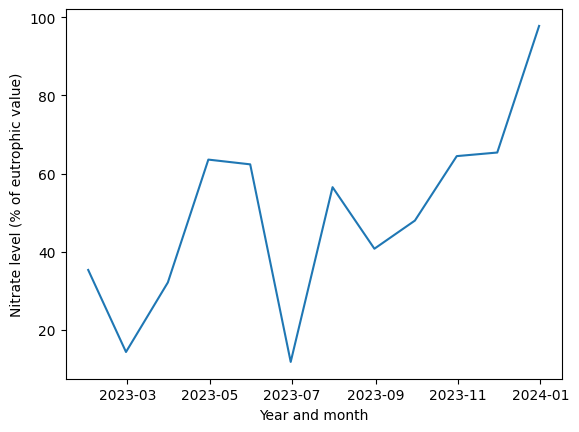

In [6]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

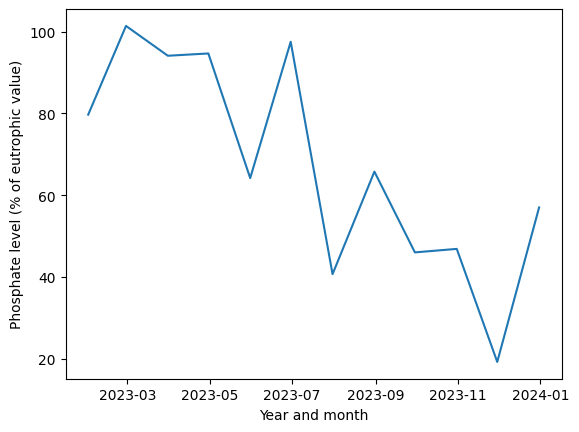

In [7]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

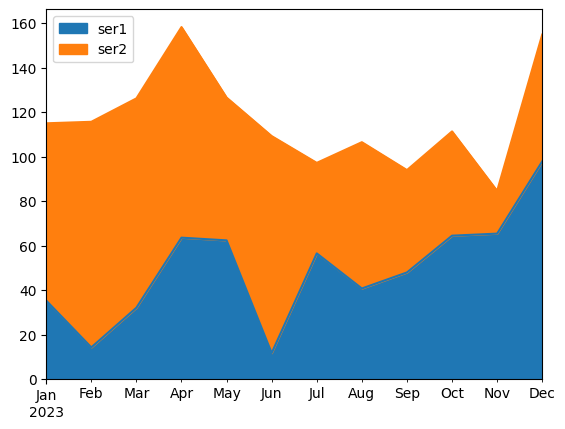

In [8]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

**Maksim Haurylik**
* Advantages of Area plots:
  * Good visualization
  * Emphasis on magnitude
* Disadvantages of an Area plots:
  * Can be harder to compare exact values

* Advantages of 2 separate line graphs
  * More clear trends
  * More accurate value comparison

* How I would improve presentation? I would do the following:
  * Use one combined line graph instead of stacked area
  * Plot both nitrate and phosphate as lines on the same axes.
  * Use different colors and a clear legend.
  * Replace “% of eutrophic value” with real units if possible (e.g., mg/L).
  * Add an infoormative title (e.g., “Monthly Nitrate and Phosphate Levels (2023)”).
  * Rotate month labels for readability

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

**Maksim Haurylik**
I will use this dataset:
Chauhan, A. S. (2024, November 24). Retail Store Inventory Forecasting Dataset. Kaggle. https://www.kaggle.com/datasets/anirudhchauhan/retail-store-inventory-forecasting-dataset

Eleni from my team (Team 57) found it last semester

In [9]:
import matplotlib.pyplot as plt

df = pd.read_csv("retail_store_inventory.csv")
print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (73100, 15)


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


<class 'pandas.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  str    
 1   Store ID            73100 non-null  str    
 2   Product ID          73100 non-null  str    
 3   Category            73100 non-null  str    
 4   Region              73100 non-null  str    
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  str    
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  str    
dtypes: float64(3), int64(5), str(7)
memory usage: 8.4 MB


None

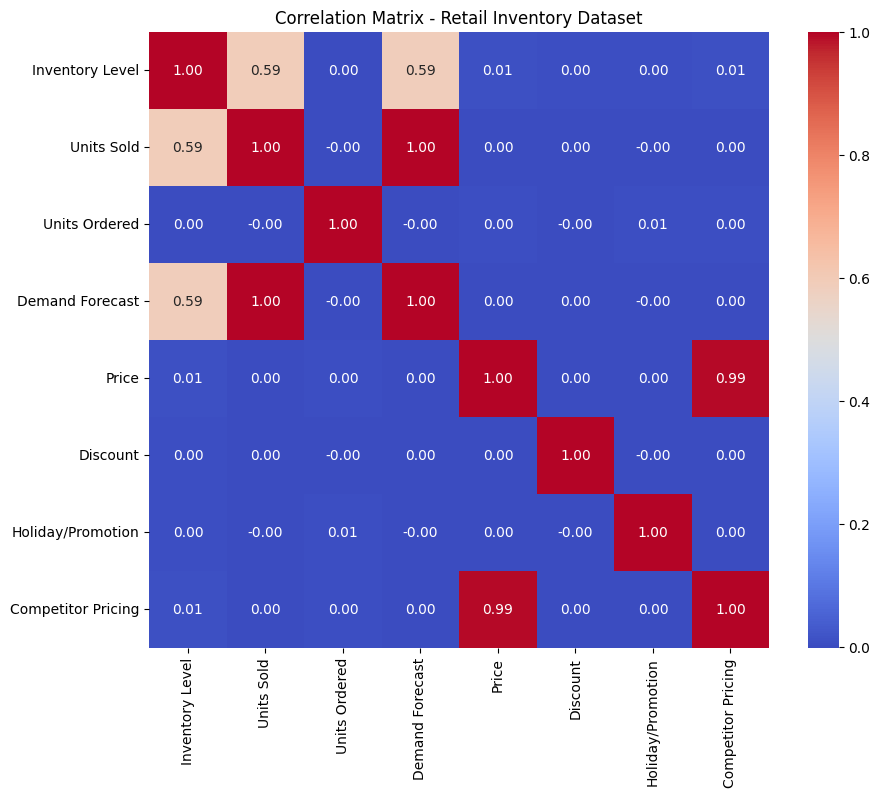

In [10]:
# Numeric only
numeric_cols = df.select_dtypes(include=np.number).columns

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix - Retail Inventory Dataset")
plt.show()

Strongest correlation between: Demand Forecast and Units Sold


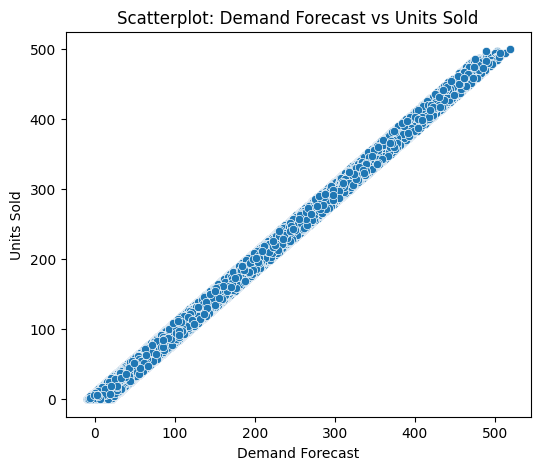

In [11]:
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked.index.get_level_values(0) != corr_unstacked.index.get_level_values(1)]
corr_unstacked = corr_unstacked.abs().sort_values(ascending=False)
top_pair = corr_unstacked.index[0]
var1, var2 = top_pair

print(f"Strongest correlation between: {var1} and {var2}")
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x=var1, y=var2)
plt.title(f"Scatterplot: {var1} vs {var2}")
plt.show()

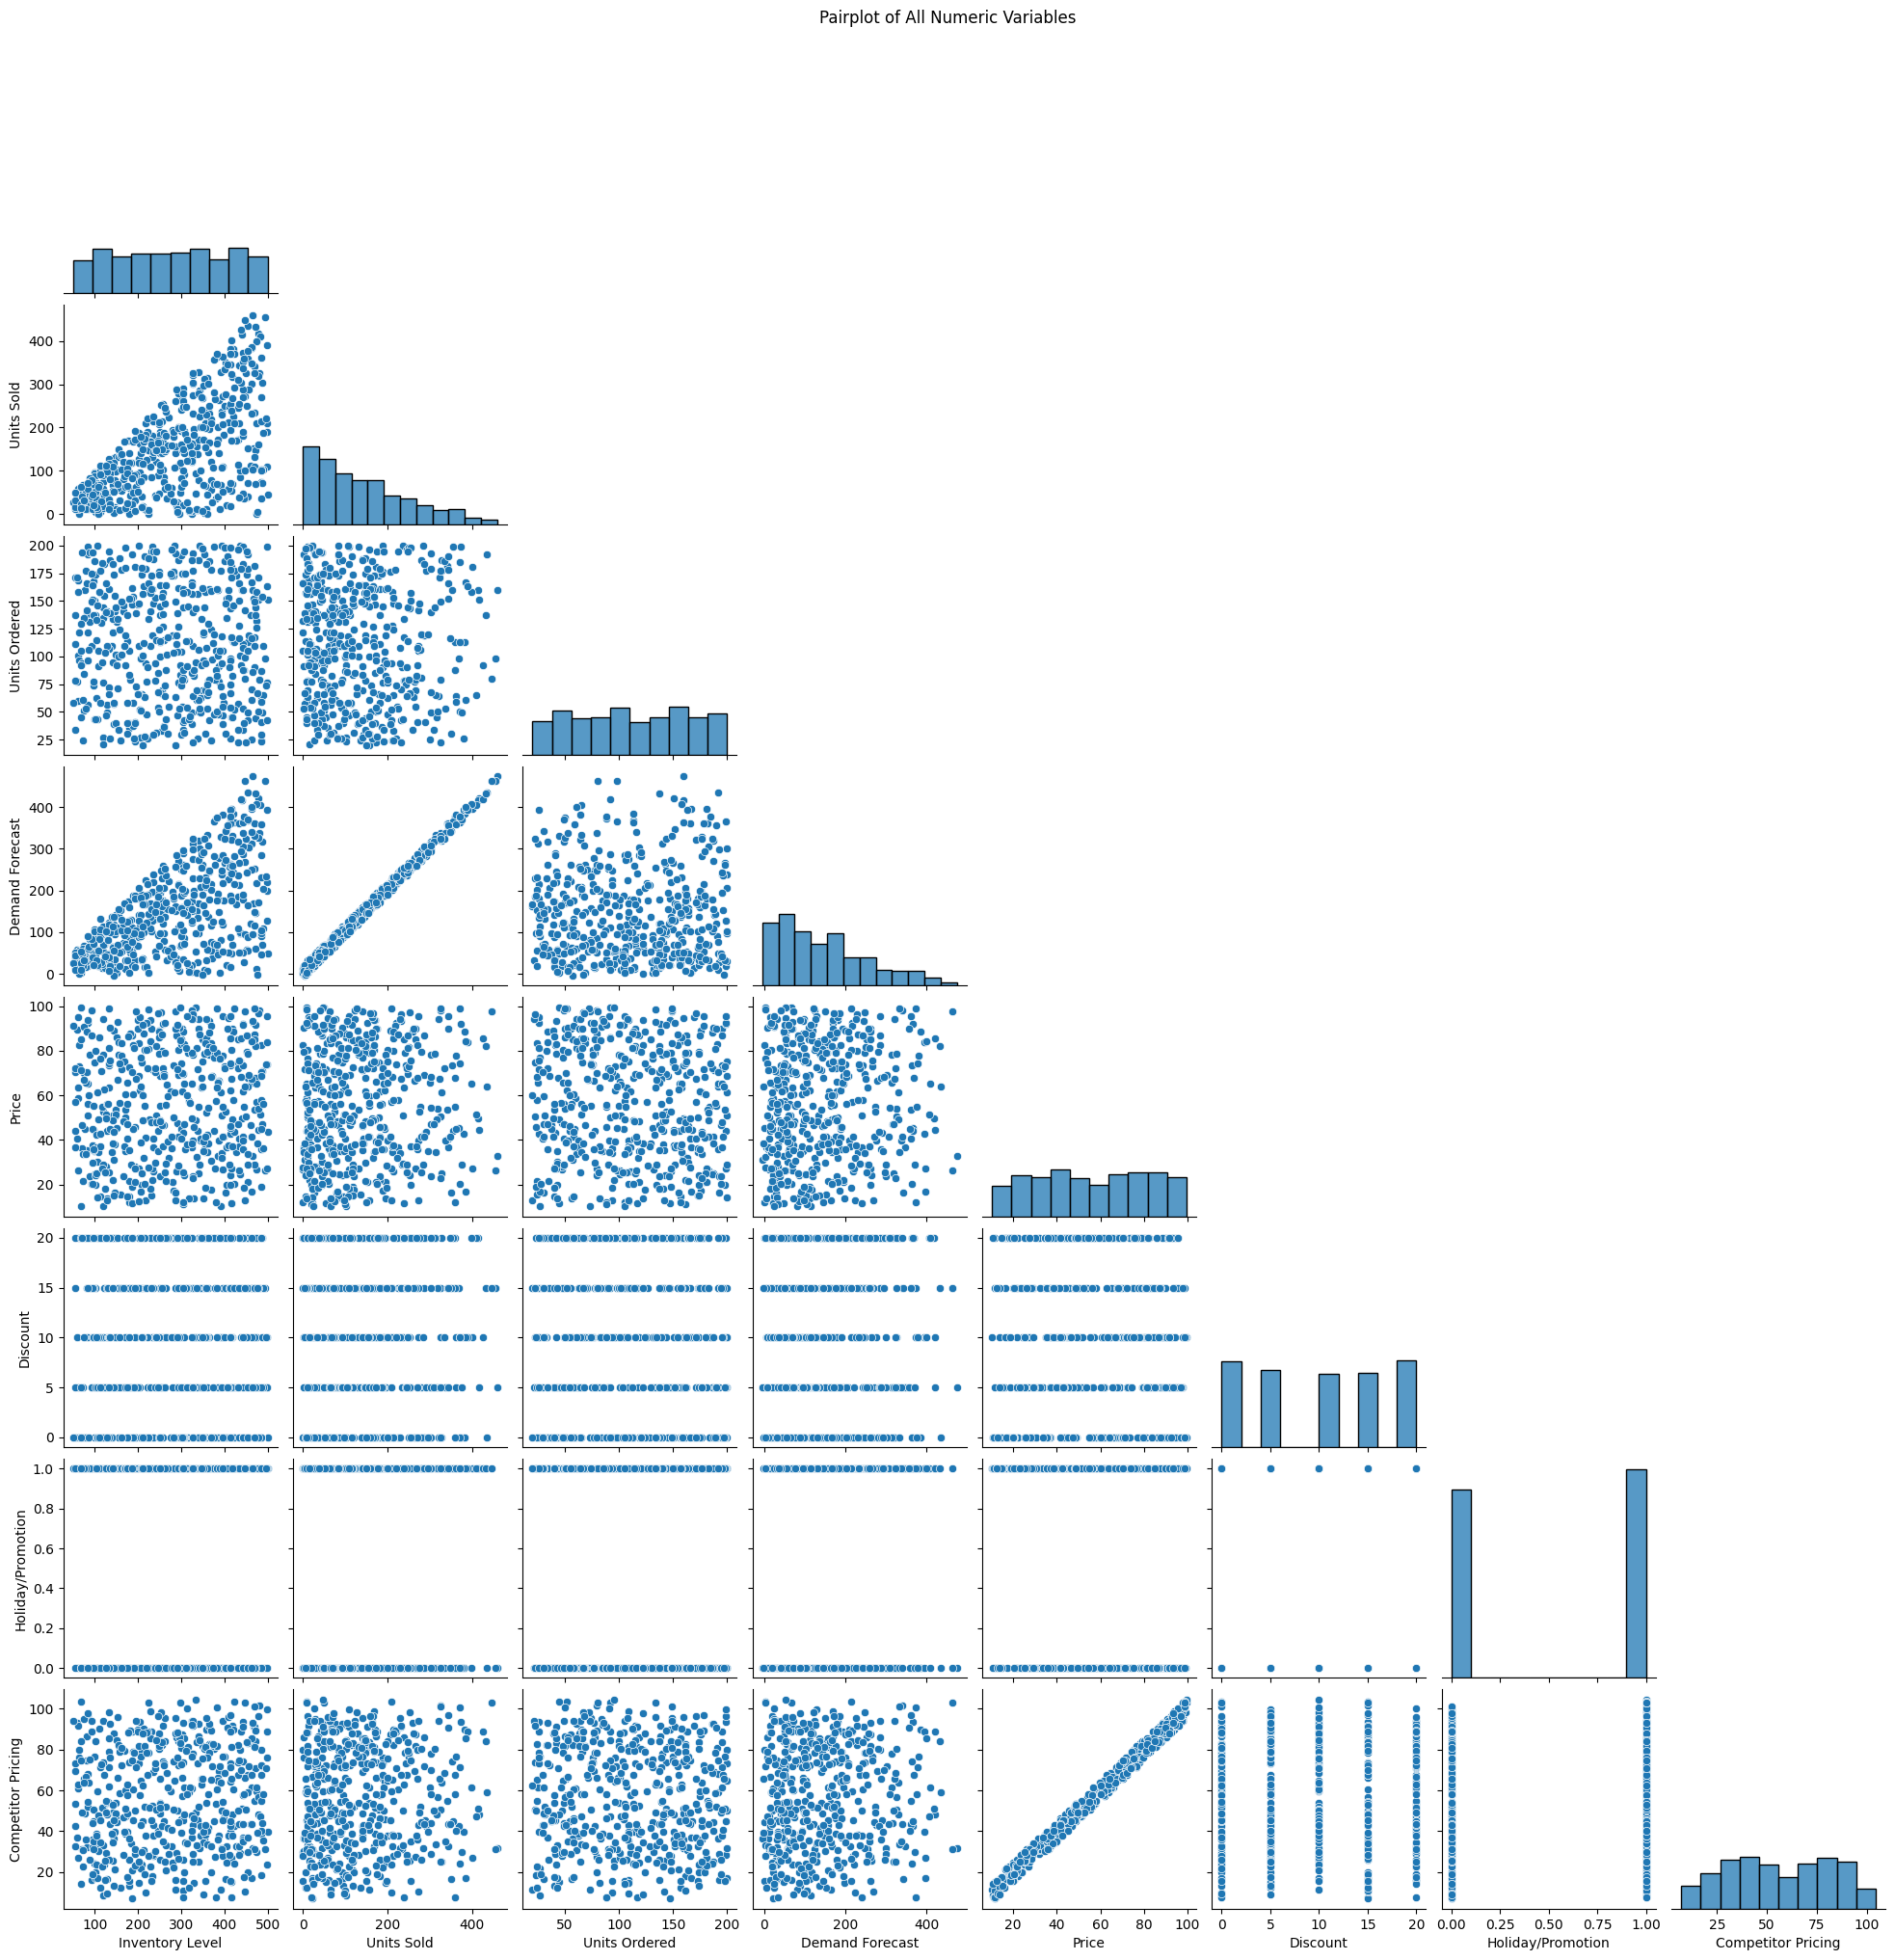

In [16]:
sns.pairplot(df[numeric_cols].sample(min(500, len(df))), corner=True)
plt.suptitle("Pairplot of All Numeric Variables", y=1.02)
plt.show()

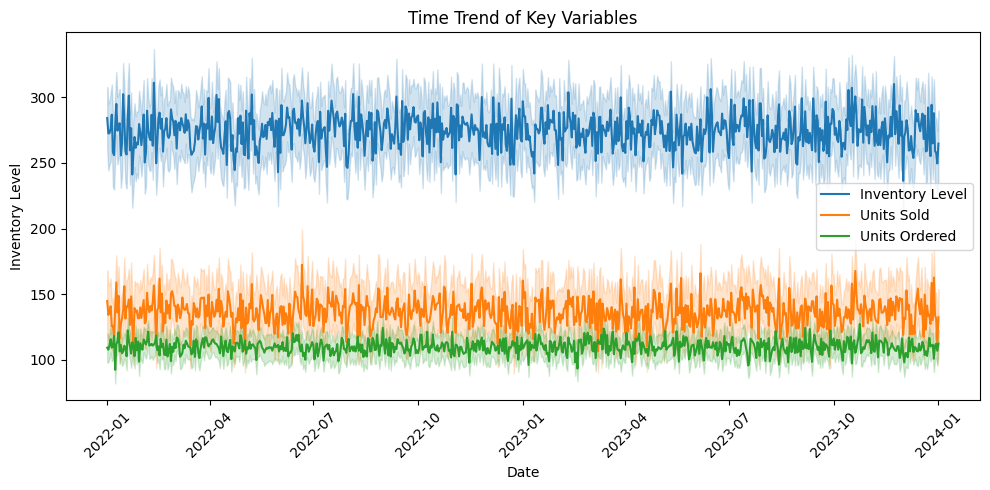

In [15]:
df["Date"] = pd.to_datetime(df["Date"])
df_time = df.sort_values("Date")
plt.figure(figsize=(10,5))

for col in numeric_cols[:3]:
    sns.lineplot(data=df_time, x="Date", y=col, label=col)

plt.title("Time Trend of Key Variables")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

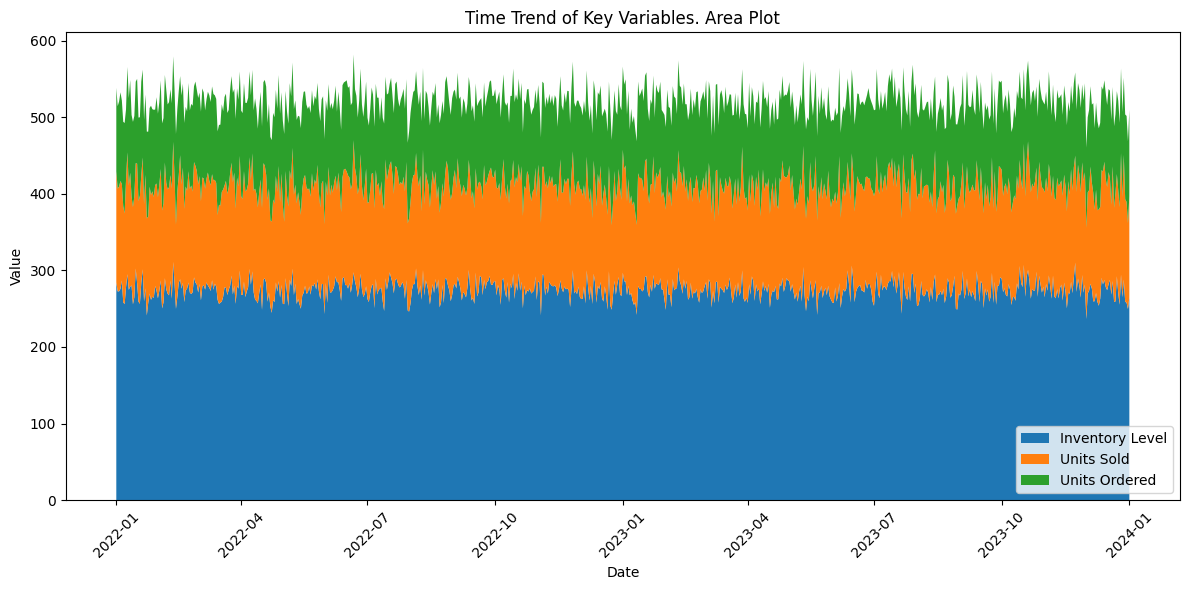

In [22]:
df["Date"] = pd.to_datetime(df["Date"])
df_time = df.sort_values("Date")
df_daily = df_time.groupby("Date")[["Inventory Level", "Units Sold", "Units Ordered"]].mean()

plt.figure(figsize=(12,6))
plt.stackplot(
    df_daily.index,
    df_daily["Inventory Level"],
    df_daily["Units Sold"],
    df_daily["Units Ordered"],
    labels=["Inventory Level", "Units Sold", "Units Ordered"]
)

plt.title("Time Trend of Key Variables. Area Plot")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend(loc="lower right") # because of these spikes, the legend doesn't look good at the top of the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




## Retail Store Inventory Forecasting Dataset. Conclusions:
### Types of Analysis Performed
- I checked the general parameteres of the dataset
- Then I created correlation matrix. Corrrelation is strong betwwen Demand Forecast and Units Sold, Price and Competitor Pricing
- Then - catterplot for Demand Forecast and Units Sold. Strong correlation, mostly linear relationship
- Pairplot: same as in correlation matrix, stron liner correlation betwwen Demand Forecast and Units Sold, Price and Competitor Pricing. Discount is int and can be only 0, 5, 10, 15, or 20 - that is why the plot for Discount looks like that
- Area graphs: no significant seasonality shown

### Conclusions
#### Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!
- Yes. it is what I expected, everything is good - it is usable and looks realistic.

#### Do you see any outliers?  (Data points that are far from the rest of the data).
- I wouldn't say so. Of course, there are certain deviations from the main cluster - but it looks like they are too insignificant to be considered outliers

#### Are any data items highly correlated with each other, suggesting that they are redundant?
- Yes. Demand Forecast and Units Sold, Price and Competitor Pricing. Potentially, maybe there is a certain redundancy

#### For the line plots, do you see a trend or pattern over time? Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?
- I thought I would - I expected seasonality. But apparently, there is nothing like that here

#### Can you think of any confounding variables? (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)
Maybe, Seasonal events or Promotional campaigns. None of them is included now


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

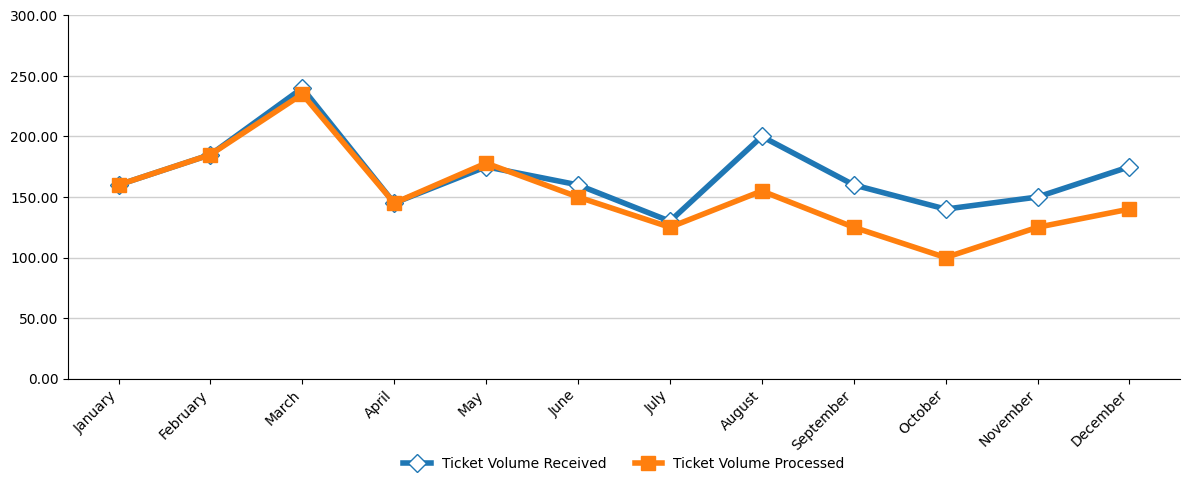

In [14]:
import matplotlib.pyplot as plt

months = ["January","February","March","April","May","June","July",
          "August","September","October","November","December"]

received  = [160, 185, 240, 145, 175, 160, 130, 200, 160, 140, 150, 175]  # blue
processed = [160, 185, 235, 145, 178, 150, 125, 155, 125, 100, 125, 140]  # red

x = np.arange(len(months))
plt.figure(figsize=(12, 5))
plt.plot(
    x, received,
    linewidth=4,
    marker='D', markersize=9,
    markerfacecolor='white',
    label='Ticket Volume Received'
)
plt.plot(
    x, processed,
    linewidth=4,
    marker='s', markersize=10,
    label='Ticket Volume Processed'
)

plt.xticks(x, months, rotation=45, ha='right')
plt.ylim(0, 300)
yticks = np.arange(0, 301, 50)
plt.yticks(yticks, [f"{v:.2f}" for v in yticks])
plt.grid(axis='y', linewidth=1, alpha=0.6)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False)
plt.tight_layout()
plt.show()